In [ ]:
import os
try:
  from google.colab import drive
  drive.mount('/content/drive')
  os.chdir("/content/drive/MyDrive/COMP530-Project")
except ImportError:
  os.chdir("../data/processed")

Mounted at /content/drive


In [2]:
import pandas as pd
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

In [3]:
import pandas as pd
df = pd.read_csv(
    "AWID3_Parsed/Evil_Twin.csv",
    escapechar='\\',
    low_memory=False,
    skiprows=range(1, 1400000),
    nrows=500000
    )

In [4]:
desc_df = df.describe().T
filtered_df = desc_df[
    (desc_df['count'] >= 300000.0) &
    (desc_df['std'] > 0)
     ]
sorted_df = filtered_df.sort_values(by='std')
display(sorted_df)

,count,mean,std,min,25%,50%,75%,max
frame.time_delta_displayed,500000.0,1.780771e-04,8.809342e-04,0.000000e+00,4.000000e-06,4.800000e-05,1.330000e-04,6.952300e-02
frame.time_delta,500000.0,1.780771e-04,8.809342e-04,0.000000e+00,4.000000e-06,4.800000e-05,1.330000e-04,6.952300e-02
wlan.fc.type,500000.0,1.417998e+00,5.012546e-01,0.000000e+00,1.000000e+00,1.000000e+00,2.000000e+00,2.000000e+00
wlan_radio.phy,500000.0,6.252920e+00,1.479496e+00,5.000000e+00,5.000000e+00,5.000000e+00,8.000000e+00,8.000000e+00
wlan.fc.subtype,500000.0,9.531412e+00,1.747801e+00,0.000000e+00,8.000000e+00,9.000000e+00,1.100000e+01,1.400000e+01
radiotap.length,500000.0,5.927357e+01,3.933878e+00,4.800000e+01,5.600000e+01,5.600000e+01,6.400000e+01,6.400000e+01
wlan_radio.signal_dbm,500000.0,-4.528226e+01,1.408858e+01,-7.500000e+01,-6.200000e+01,-3.400000e+01,-3.300000e+01,-2.800000e+01
frame.time_epoch,500000.0,1.608066e+09,2.324319e+01,1.608066e+09,1.608066e+09,1.608066e+09,1.608066e+09,1.608066e+09
frame.time_relative,500000.0,4.769955e+02,2.324319e+01,4.315987e+02,4.598870e+02,4.789026e+02,4.911417e+02,5.206373e+02
wlan_radio.data_rate,500000.0,6.684477e+01,5.876474e+01,6.000000e+00,2.400000e+01,2.400000e+01,1.300000e+02,1.733333e+02


In [7]:
if 'ip.addr' in df.columns:
    display(df['ip.addr'].value_counts())
else:
    print("'ip.addr' column not found in the DataFrame.")

,count
ip.addr,
"192.168.30.1,192.168.30.136",15352
"192.168.2.21,192.168.2.19",11374
"104.16.237.230,192.168.2.125",10175
"62.75.54.77,192.168.2.254",9475
"62.75.23.76,192.168.2.73",9343
"52.85.156.201,192.168.2.190",7015
"52.85.156.201,192.168.2.73",6979
"104.16.236.230,192.168.2.73",6334
"52.85.156.107,192.168.2.125",5987


In [11]:
import numpy as np

condition = (
    ((df['wlan.fc.subtype'] == 8) & (df['frame.len'] < 242)) |
    (( (df['wlan.fc.subtype'] == 10) | (df['wlan.fc.subtype'] == 12) | (df['wlan.fc.subtype'] == 40) ) & (df['wlan.fc.protected'] == 0))
) & (df['frame.number'] >= 1420038) & (df['frame.number'] <= 3778728) & (
    (df['ip.addr'].str.contains('192.168.30.1') ) | (df['wlan.addr'].str.contains('0c:9d:92:54:fe:35'))
)

df['label'] = np.where(condition, 'evil_twin', 'normal')

# Display the count of each label to verify
display(df['label'].value_counts())

,count
label,
normal,493552
evil_twin,6448


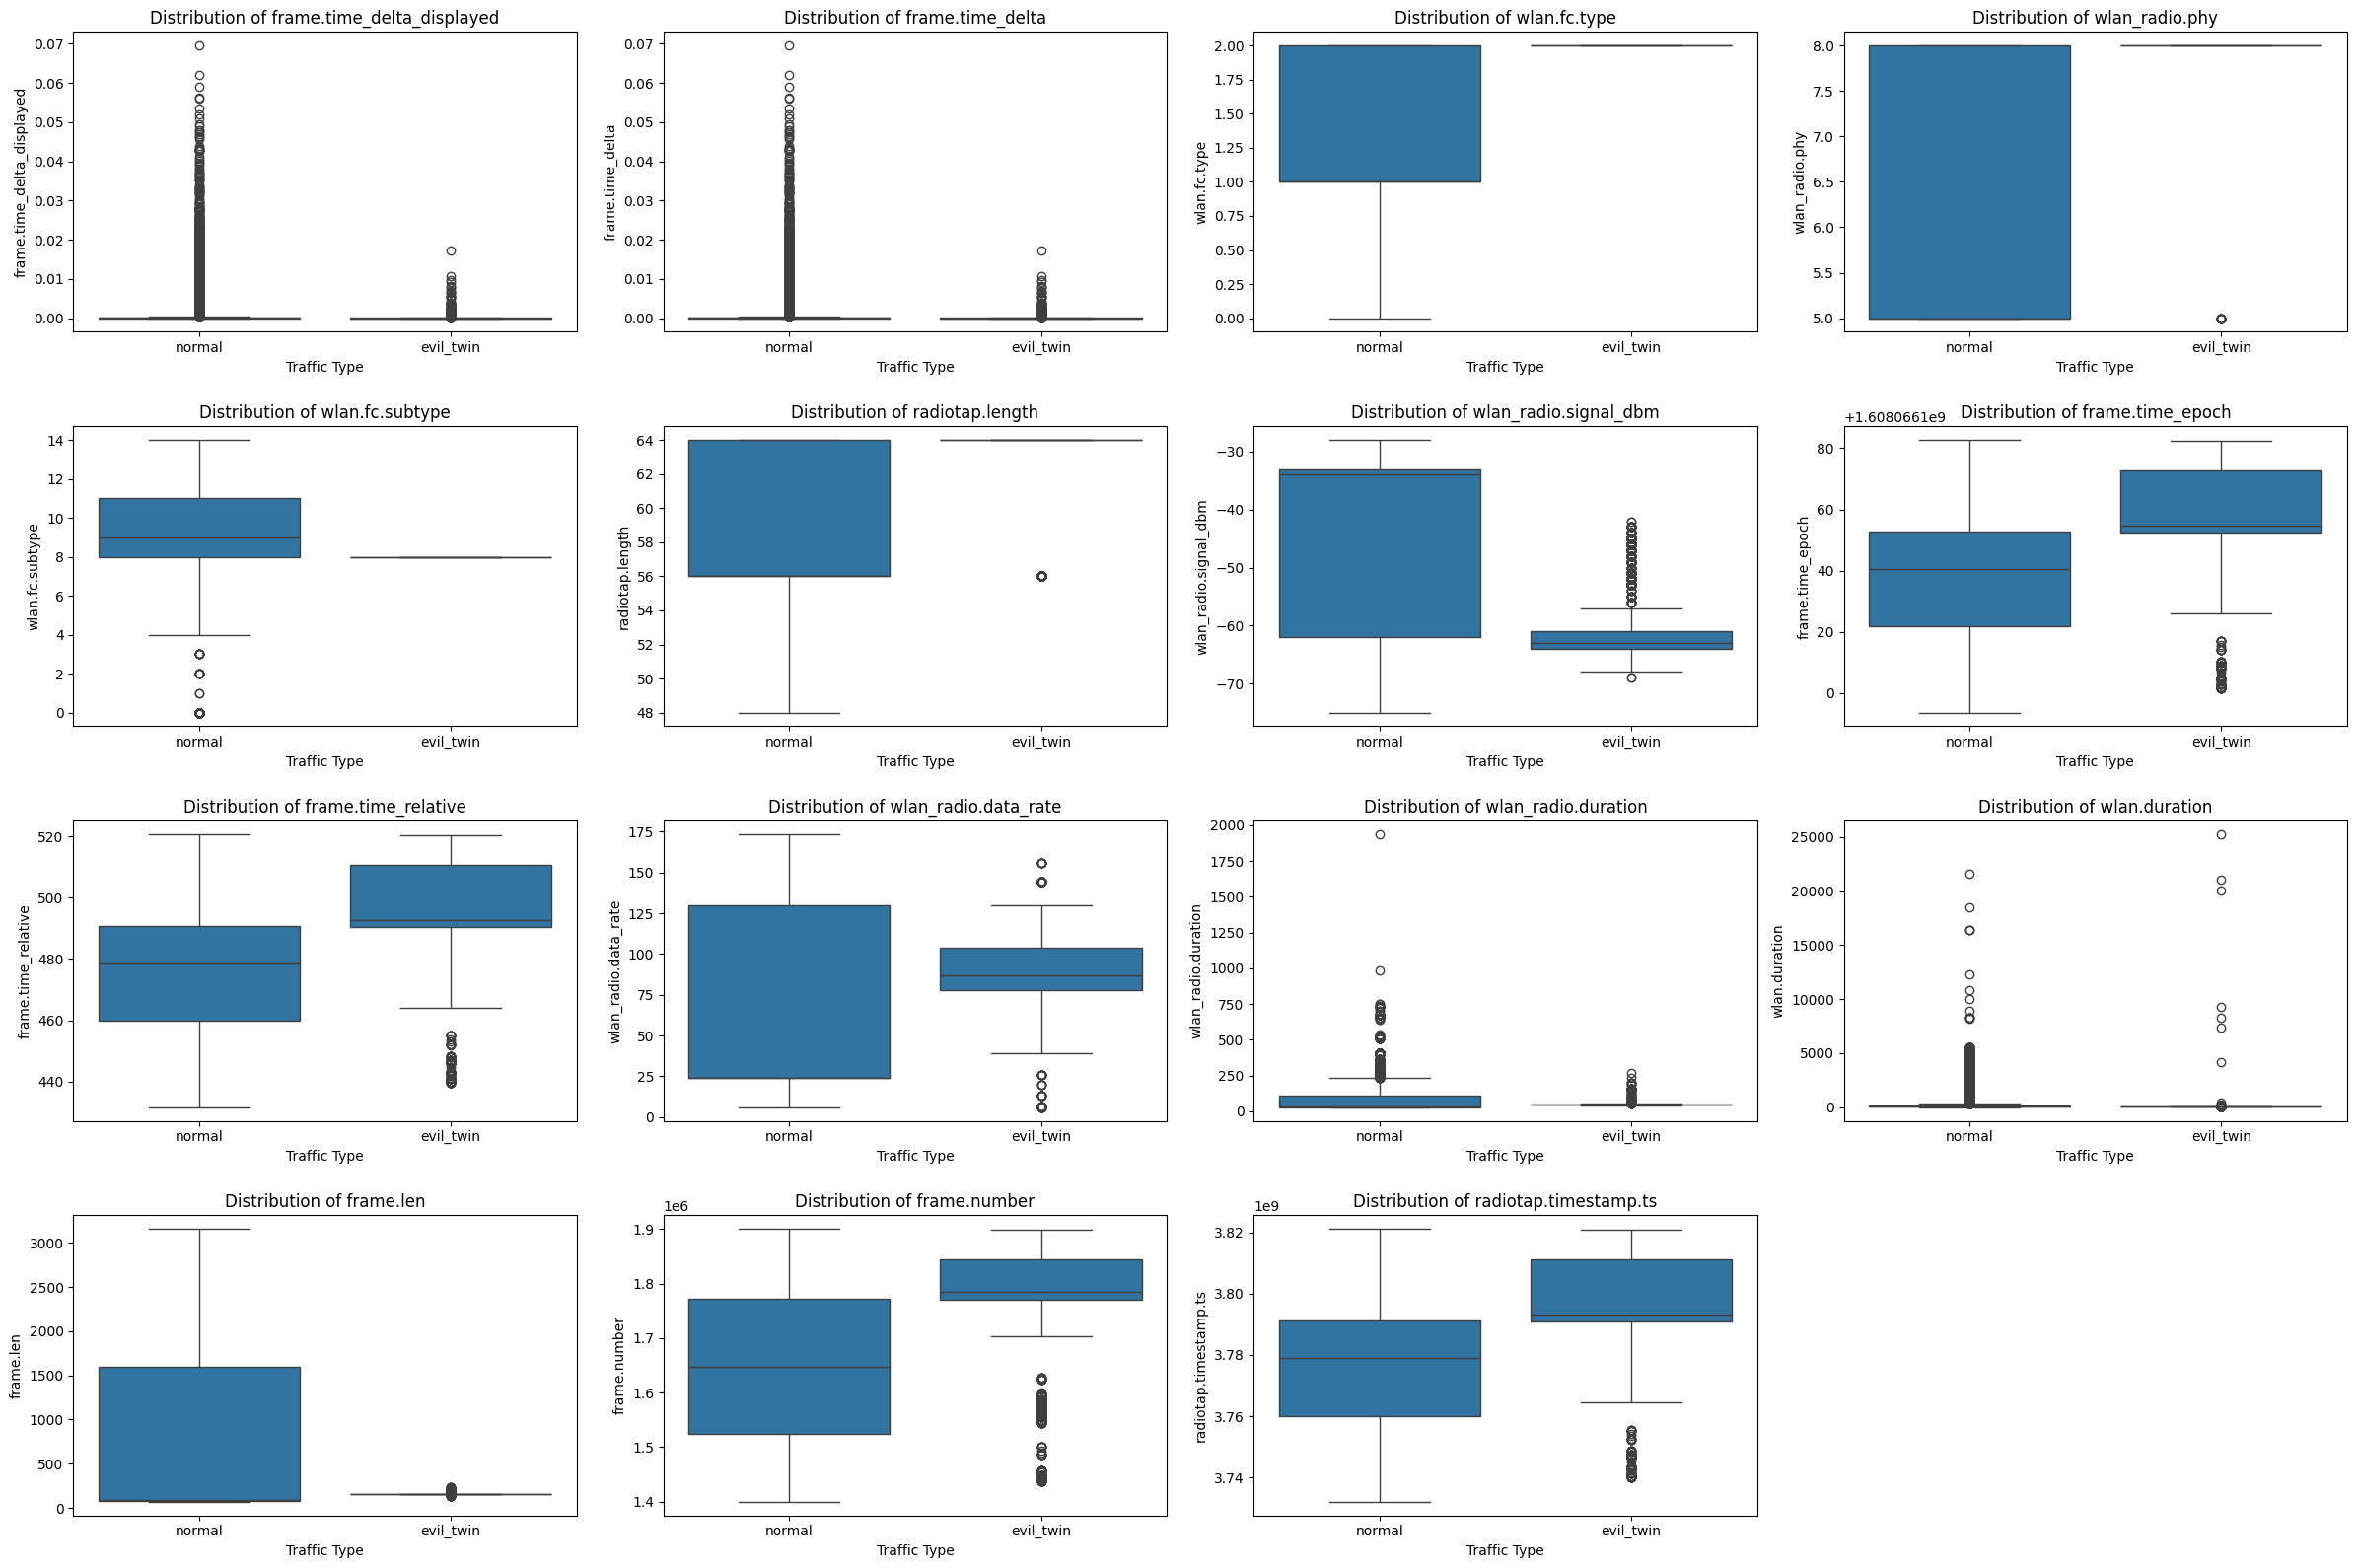

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get the list of columns to plot from the index of sorted_df
columns_to_plot = sorted_df.index.tolist()

# Determine grid dimensions for subplots
num_columns = len(columns_to_plot)
num_cols_grid = 4  # Adjust as needed
num_rows_grid = (num_columns + num_cols_grid - 1) // num_cols_grid

fig, axes = plt.subplots(num_rows_grid, num_cols_grid, figsize=(num_cols_grid * 6, num_rows_grid * 4))
axes = axes.flatten() # Flatten the 2D array of axes for easy iteration

for i, col in enumerate(columns_to_plot):
    sns.boxplot(x='label', y=col, data=df, ax=axes[i])
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel('Traffic Type')
    axes[i].set_ylabel(col)

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()